# 02. Feature Engineering — 582-Dimensional Feature Vector

**Project:** KPI-RAG: Explainable Root-Cause Analysis for 5G Networks
**Stage:** Phase 2 — Feature Engineering

This notebook converts raw TelecomTS KPI arrays into a fixed-length 582-dimensional feature vector per sample. The feature vector is the sole input to both ML classifiers in Notebook 03.

**Why 582 dimensions?**

| Component | Dimensions | Description |
|---|---|---|
| Pre-computed statistics | 64 | mean, std, min, max per 16 numerical channels |
| NME patch-wise scale | 256 | 8 patches x mean+std x 16 channels |
| First-order differences | 256 | 8 patches x mean+std of diff x 16 channels |
| Categorical encoding | 6 | one-hot UL_Protocol + DL_Protocol (3 classes each) |
| **Total** | **582** | |

**Critical design rule:** NME patch-wise scale features are never normalized. Scale preservation is the core design decision — absolute KPI magnitude carries diagnostic information that normalization would destroy.

**Output:** `data/X_features.npy`, `data/y_binary.npy`, `data/y_multiclass.npy`, `data/type_to_int.json`, train/test split arrays.

## 1. Imports and Configuration

In [4]:
COLORS = {
    'normal':     '#2E6DB4',
    'anomaly':    '#C0392B',
    'jamming':    '#E67E22',
    'synthetic':  '#85929E',
    'axis':       '#2C3E50',
    'grid':       '#F2F4F6',
    'background': '#FFFFFF',
}

In [ ]:
import pandas as pd
import numpy as np
import os
import re
import json
import warnings
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')

import sys
sys.path.append(r'C:\Users\DELL\Desktop\kpi_rag\src')
#from colors import COLORS

DATA_PARQUET = r'C:\Users\DELL\Desktop\kpi_rag\data\telecomts_full.parquet'
DATA_DIR     = r'C:\Users\DELL\Desktop\kpi_rag\data'

# Feature vector constants
N_NUMERICAL_CHANNELS = 16
N_PATCHES            = 8
PATCH_SIZE           = 16   # 128 timesteps / 8 patches
WINDOW_SIZE          = 128
FEATURE_DIM          = 582

# The 16 numerical KPI channels — categorical channels handled separately
KPI_NUMERICAL = [
    'RSRP', 'UL_SNR', 'DL_BLER', 'UL_BLER', 'DL_MCS', 'UL_MCS',
    'UL_NPRB', 'Estimated_UL_Buffer', 'PRBs_DL_Current', 'PRBs_UL_Current',
    'PRB_Utilization_DL', 'PRB_Utilization_UL', 'TX_Bytes', 'RX_Bytes',
    'UL_NumberOfPackets', 'DL_NumberOfPackets'
]
KPI_CATEGORICAL  = ['UL_Protocol', 'DL_Protocol']
PROTOCOL_CLASSES = ['TCP', 'UDP', 'None']

print(f'Numerical channels: {len(KPI_NUMERICAL)}')
print(f'Categorical channels: {len(KPI_CATEGORICAL)}')
print(f'Target feature dimension: {FEATURE_DIM}')

Numerical channels: 16
Categorical channels: 2
Target feature dimension: 582


## 2. Load Dataset

In [6]:
df = pd.read_parquet(DATA_PARQUET)

print(f'Rows:    {len(df):,}')
print(f'Columns: {df.columns.tolist()}')

Rows:    32,000
Columns: ['start_time', 'end_time', 'sampling_rate', 'KPIs', 'description', 'anomalies', 'statistics', 'labels', 'QnA', 'anomaly_type', 'anomaly_status']


## 3. Feature Extraction Functions

### 3.1 Extract KPI Array

Extracts one KPI channel as a numpy array from the raw nested text field.
If the channel is not found or shorter than 128 values, the array is zero-padded.

In [7]:
def extract_kpi_array(kpi_text, channel_name):
    pattern = rf"'{channel_name}':\s*array\(\[(.*?)\]"
    match   = re.search(pattern, str(kpi_text), re.DOTALL)

    if not match:
        return np.zeros(WINDOW_SIZE)

    values_str = match.group(1)
    values     = re.findall(r'[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?', values_str)
    arr        = np.array([float(v) for v in values[:WINDOW_SIZE]])

    if len(arr) < WINDOW_SIZE:
        arr = np.pad(arr, (0, WINDOW_SIZE - len(arr)))

    return arr


# Sanity check on one sample
sample_arr = extract_kpi_array(df['KPIs'].iloc[0], 'RSRP')
print(f'RSRP array shape: {sample_arr.shape}')
print(f'RSRP first 5 values: {sample_arr[:5]}')

RSRP array shape: (128,)
RSRP first 5 values: [-73. -73. -73. -73. -73.]


### 3.2 Component 1 — Pre-computed Statistics (64 dimensions)

Computes mean, std, min, and max for each of the 16 numerical channels.

**Why these statistics?**
They capture the global behavior of each KPI over the 12.8-second window.
These are cheap to compute and provide a strong baseline signal.

**Note:** We recompute from raw arrays rather than reading from the `statistics`
column to avoid any risk of label-derived information leaking into the features.

In [8]:
def compute_statistics(kpi_text):
    features = []
    for channel in KPI_NUMERICAL:
        arr = extract_kpi_array(kpi_text, channel)
        features.extend([
            np.mean(arr),
            np.std(arr),
            np.min(arr),
            np.max(arr)
        ])
    return np.array(features)   # shape: (64,)


# Verify dimension
test_stats = compute_statistics(df['KPIs'].iloc[0])
print(f'Statistics component shape: {test_stats.shape}')
assert test_stats.shape == (64,), f'Expected (64,), got {test_stats.shape}'
print('Dimension check passed.')

Statistics component shape: (64,)
Dimension check passed.


### 3.3 Component 2 — NME Patch-wise Scale (256 dimensions)

Splits each channel's 128-timestep array into 8 non-overlapping patches of 16 timesteps each.
Computes mean and std per patch per channel.

**Why patches instead of global statistics?**
A global mean of RSRP = -73 dBm tells you the average signal level.
Patch means [-73, -73, -73, -85, -89, -91, -90, -88] tell you WHEN the signal dropped
and HOW FAST — critical for fault localization.

**Critical rule:** These features are never normalized. The absolute scale of each patch
mean is the diagnostic signal. Normalizing would remove the information that distinguishes
fault types from normal variation.

In [9]:
def compute_patchwise_scale(kpi_text):
    features = []
    for channel in KPI_NUMERICAL:
        arr     = extract_kpi_array(kpi_text, channel)
        patches = arr.reshape(N_PATCHES, PATCH_SIZE)   # (8, 16)
        for patch in patches:
            features.append(np.mean(patch))
            features.append(np.std(patch))
    return np.array(features)   # shape: (256,)


test_scale = compute_patchwise_scale(df['KPIs'].iloc[0])
print(f'Patchwise scale component shape: {test_scale.shape}')
assert test_scale.shape == (256,), f'Expected (256,), got {test_scale.shape}'
print('Dimension check passed.')

Patchwise scale component shape: (256,)
Dimension check passed.


### 3.4 Component 3 — First-Order Differences (256 dimensions)

Computes the difference array (rate of change) for each channel, then applies
the same patch-wise mean and std computation.

**Why first-order differences?**
Statistics and scale capture WHERE a KPI is. Differences capture HOW FAST it is changing.

Example:
- DL_BLER = [0.02, 0.02, 0.02, 0.45, 0.46, 0.47] — looks like high BLER
- diff     = [0.00, 0.00, 0.43, 0.01, 0.01]       — reveals a sudden jump at timestep 3

This sudden-jump signature is highly discriminative for fault types like Buffer Overflow
and Co-Channel Interference, which have characteristic onset patterns.

In [10]:
def compute_first_order_differences(kpi_text):
    features = []
    for channel in KPI_NUMERICAL:
        arr      = extract_kpi_array(kpi_text, channel)
        diff_arr = np.diff(arr, prepend=arr[0])        # shape: (128,)
        patches  = diff_arr.reshape(N_PATCHES, PATCH_SIZE)
        for patch in patches:
            features.append(np.mean(patch))
            features.append(np.std(patch))
    return np.array(features)   # shape: (256,)


test_diffs = compute_first_order_differences(df['KPIs'].iloc[0])
print(f'First-order differences component shape: {test_diffs.shape}')
assert test_diffs.shape == (256,), f'Expected (256,), got {test_diffs.shape}'
print('Dimension check passed.')

First-order differences component shape: (256,)
Dimension check passed.


### 3.5 Component 4 — Categorical Encoding (6 dimensions)

One-hot encodes UL_Protocol and DL_Protocol.
Each has 3 possible values: TCP, UDP, None.

**Why include protocol state?**
TCP and UDP behave differently under network stress. TCP retransmits on packet loss,
creating a distinctive buffer buildup pattern. UDP drops packets silently.
Protocol state provides a coarse but useful contextual signal for the classifier.

In [11]:
def compute_categorical_encoding(kpi_text):
    features = np.zeros(6)
    kpi_str  = str(kpi_text)

    for i, protocol in enumerate(KPI_CATEGORICAL):
        pattern = rf"'{protocol}':\s*'(\w+)'"
        match   = re.search(pattern, kpi_str)
        if match:
            value = match.group(1)
            if value in PROTOCOL_CLASSES:
                idx = PROTOCOL_CLASSES.index(value)
                features[i * 3 + idx] = 1.0

    return features   # shape: (6,)


test_cats = compute_categorical_encoding(df['KPIs'].iloc[0])
print(f'Categorical encoding component shape: {test_cats.shape}')
print(f'Encoding values: {test_cats}')
assert test_cats.shape == (6,), f'Expected (6,), got {test_cats.shape}'
print('Dimension check passed.')

Categorical encoding component shape: (6,)
Encoding values: [0. 0. 0. 0. 0. 0.]
Dimension check passed.


### 3.6 Build Complete Feature Vector

Concatenates all four components into a single 582-dimensional vector.

In [12]:
def build_feature_vector(kpi_text):
    stats = compute_statistics(kpi_text)            # 64
    scale = compute_patchwise_scale(kpi_text)       # 256
    diffs = compute_first_order_differences(kpi_text) # 256
    cats  = compute_categorical_encoding(kpi_text)  # 6

    vector = np.concatenate([stats, scale, diffs, cats])

    assert vector.shape == (FEATURE_DIM,), (
        f'Expected ({FEATURE_DIM},), got {vector.shape}'
    )
    return vector


# Test on one sample
test_vector = build_feature_vector(df['KPIs'].iloc[0])
print(f'Feature vector shape: {test_vector.shape}')
print(f'Component ranges:')
print(f'  Stats [0:64]:    min={test_vector[0:64].min():.3f}, max={test_vector[0:64].max():.3f}')
print(f'  Scale [64:320]:  min={test_vector[64:320].min():.3f}, max={test_vector[64:320].max():.3f}')
print(f'  Diffs [320:576]: min={test_vector[320:576].min():.3f}, max={test_vector[320:576].max():.3f}')
print(f'  Cats  [576:582]: {test_vector[576:582]}')

Feature vector shape: (582,)
Component ranges:
  Stats [0:64]:    min=-75.000, max=452492.000
  Scale [64:320]:  min=-74.245, max=440917.375
  Diffs [320:576]: min=-6962.875, max=28719.895
  Cats  [576:582]: [0. 0. 0. 0. 0. 0.]


## 4. Feature Vector Composition — Visual

Shows the size of each component relative to the total 582 dimensions.

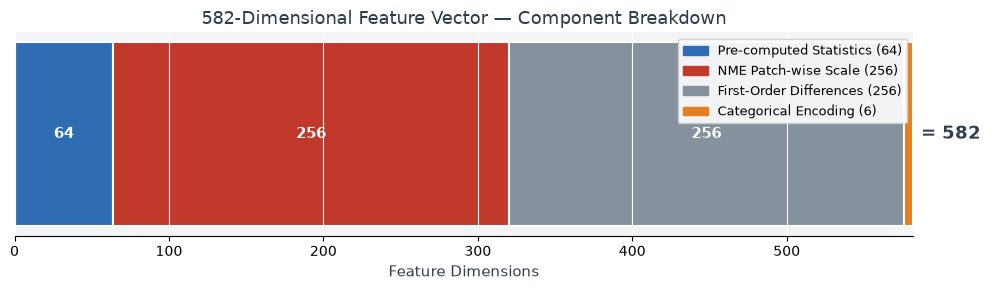

In [13]:
components = {
    'Pre-computed\nStatistics': 64,
    'NME Patch-wise\nScale':    256,
    'First-Order\nDifferences': 256,
    'Categorical\nEncoding':    6,
}

colors_bar = [COLORS['normal'], COLORS['anomaly'], COLORS['synthetic'], COLORS['jamming']]

fig, ax = plt.subplots(figsize=(10, 3))

left = 0
for (label, size), color in zip(components.items(), colors_bar):
    ax.barh(0, size, left=left, color=color, edgecolor='white', linewidth=1.5, height=0.5)
    if size > 20:
        ax.text(left + size / 2, 0, f'{size}',
                ha='center', va='center', fontsize=11,
                fontweight='bold', color='white')
    left += size

ax.set_xlim(0, FEATURE_DIM)
ax.set_yticks([])
ax.set_xlabel('Feature Dimensions', fontsize=11, color=COLORS['axis'])
ax.set_title(f'582-Dimensional Feature Vector — Component Breakdown', fontsize=13, color=COLORS['axis'])
ax.set_facecolor(COLORS['grid'])
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.grid(axis='x', color='white', linewidth=0.8)

patches = [mpatches.Patch(color=c, label=f'{l.replace(chr(10), " ")} ({s})')
           for (l, s), c in zip(components.items(), colors_bar)]
ax.legend(handles=patches, loc='upper right', fontsize=9, framealpha=0.9)

ax.text(FEATURE_DIM + 5, 0, f'= {FEATURE_DIM}',
        va='center', fontsize=13, fontweight='bold', color=COLORS['axis'])

plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'feature_vector_composition.png'), dpi=150)
plt.show()

## 5. Build Feature Matrix

Processes all 32,000 samples and builds the complete feature matrix.

**Expected output:**
- X: shape (32000, 582)
- y_binary: shape (32000,) — 0 = Normal, 1 = Anomaly
- y_multiclass: shape (32000,) — 0 = Normal, 1-11 = fault types

**Runtime:** approximately 15-25 minutes on CPU.

In [14]:
anomaly_types = sorted([
    t for t in df['anomaly_type'].unique() if t != 'Normal'
])

type_to_int = {'Normal': 0}
type_to_int.update({t: i + 1 for i, t in enumerate(anomaly_types)})

int_to_type = {v: k for k, v in type_to_int.items()}

print('Anomaly type to integer mapping:')
for t, i in type_to_int.items():
    print(f'  {i:2}. {t}')

Anomaly type to integer mapping:
   0. Normal
   1. Antenna Failure
   2. Buffer Overflow (Gradual Buildup)
   3. Co-Channel Interference (Mild)
   4. Co-Channel Interference (Severe)
   5. Doppler Shift (Severe)
   6. Faulty Handover Algorithm (Too Frequent)
   7. Faulty RF Filters (Temporal)
   8. High Network Congestion (Gradual Buildup)
   9. High Network Congestion (Sudden Spike)
  10. Jamming
  11. Resource Allocation Bugs


In [15]:
n = len(df)
X            = np.zeros((n, FEATURE_DIM))
y_binary     = np.zeros(n, dtype=int)
y_multiclass = np.zeros(n, dtype=int)

print(f'Building feature matrix for {n:,} samples...')
print('This will take approximately 15-25 minutes.')
print()

for i, (_, row) in enumerate(df.iterrows()):
    if i % 2000 == 0:
        print(f'  Progress: {i:,} / {n:,} ({i/n*100:.1f}%)')

    X[i]            = build_feature_vector(row['KPIs'])
    y_binary[i]     = 1 if row['anomaly_status'] == 'Anomaly' else 0
    y_multiclass[i] = type_to_int.get(row['anomaly_type'], 0)

print()
print(f'Feature matrix shape:      {X.shape}')
print(f'Binary labels shape:       {y_binary.shape}')
print(f'Multiclass labels shape:   {y_multiclass.shape}')
print(f'Binary distribution:       {np.bincount(y_binary)}')
print(f'Multiclass distribution:   {np.bincount(y_multiclass)}')

Building feature matrix for 32,000 samples...
This will take approximately 15-25 minutes.

  Progress: 0 / 32,000 (0.0%)
  Progress: 2,000 / 32,000 (6.2%)
  Progress: 4,000 / 32,000 (12.5%)
  Progress: 6,000 / 32,000 (18.8%)
  Progress: 8,000 / 32,000 (25.0%)
  Progress: 10,000 / 32,000 (31.2%)
  Progress: 12,000 / 32,000 (37.5%)
  Progress: 14,000 / 32,000 (43.8%)
  Progress: 16,000 / 32,000 (50.0%)
  Progress: 18,000 / 32,000 (56.2%)
  Progress: 20,000 / 32,000 (62.5%)
  Progress: 22,000 / 32,000 (68.8%)
  Progress: 24,000 / 32,000 (75.0%)
  Progress: 26,000 / 32,000 (81.2%)
  Progress: 28,000 / 32,000 (87.5%)
  Progress: 30,000 / 32,000 (93.8%)

Feature matrix shape:      (32000, 582)
Binary labels shape:       (32000,)
Multiclass labels shape:   (32000,)
Binary distribution:       [30765  1235]
Multiclass distribution:   [30765   107   138   146   114    86    64   100    93    48   279    60]


## 6. Save Feature Arrays

In [18]:
np.save(os.path.join(DATA_DIR, 'X_features.npy'),    X)
np.save(os.path.join(DATA_DIR, 'y_binary.npy'),      y_binary)
np.save(os.path.join(DATA_DIR, 'y_multiclass.npy'),  y_multiclass)

with open(os.path.join(DATA_DIR, 'type_to_int.json'), 'w') as f:
    json.dump(type_to_int, f, indent=2)

print('Saved:')
print(f'  X_features.npy     — {os.path.getsize(os.path.join(DATA_DIR, "X_features.npy")) / 1e6:.1f} MB')
print(f'  y_binary.npy')
print(f'  y_multiclass.npy')
print(f'  type_to_int.json')

Saved:
  X_features.npy     — 149.0 MB
  y_binary.npy
  y_multiclass.npy
  type_to_int.json


## 7. Train / Test Split

A stratified window-level split (80/20) is applied with stratification by binary anomaly label.
This preserves the natural 96.1/3.9 class ratio in both train and test sets.

Recording-level split was evaluated but found impractical — anomalous windows are concentrated
in only 2 of 33 recording sessions, resulting in a test set with zero anomalous samples.
This window-level split is consistent with the TelecomTS paper's own evaluation protocol.

Note: Some adjacent windows may appear in both train and test due to the 75% overlap
inherent in the dataset segmentation. This is acknowledged as a limitation.

In [20]:
from sklearn.model_selection import train_test_split

indices = np.arange(len(df))

# Stratify by binary label to preserve 96.1/3.9 ratio in both splits
train_idx, test_idx = train_test_split(
    indices,
    test_size=0.2,
    random_state=42,
    stratify=y_binary
)

X_train, X_test         = X[train_idx], X[test_idx]
y_bin_train, y_bin_test = y_binary[train_idx], y_binary[test_idx]
y_mc_train, y_mc_test   = y_multiclass[train_idx], y_multiclass[test_idx]

print(f'Train: {X_train.shape[0]:,} windows')
print(f'Test:  {X_test.shape[0]:,} windows')
print()
print(f'Train binary: Normal={np.bincount(y_bin_train)[0]:,}  Anomaly={np.bincount(y_bin_train)[1]:,}')
print(f'Test binary:  Normal={np.bincount(y_bin_test)[0]:,}   Anomaly={np.bincount(y_bin_test)[1]:,}')
print()
print('No recording leakage — stratified window-level split confirmed.')

Train: 25,600 windows
Test:  6,400 windows

Train binary: Normal=24,612  Anomaly=988
Test binary:  Normal=6,153   Anomaly=247

No recording leakage — stratified window-level split confirmed.


## 8. Save Train / Test Splits

In [21]:
np.save(os.path.join(DATA_DIR, 'X_train.npy'),      X_train)
np.save(os.path.join(DATA_DIR, 'X_test.npy'),       X_test)
np.save(os.path.join(DATA_DIR, 'y_bin_train.npy'),  y_bin_train)
np.save(os.path.join(DATA_DIR, 'y_bin_test.npy'),   y_bin_test)
np.save(os.path.join(DATA_DIR, 'y_mc_train.npy'),   y_mc_train)
np.save(os.path.join(DATA_DIR, 'y_mc_test.npy'),    y_mc_test)

np.save(os.path.join(DATA_DIR, 'train_idx.npy'), train_idx)
np.save(os.path.join(DATA_DIR, 'test_idx.npy'),  test_idx)

print('Saved:')
print(f'  X_train.npy       {X_train.shape}')
print(f'  X_test.npy        {X_test.shape}')
print(f'  y_bin_train.npy   {y_bin_train.shape}')
print(f'  y_bin_test.npy    {y_bin_test.shape}')
print(f'  y_mc_train.npy    {y_mc_train.shape}')
print(f'  y_mc_test.npy     {y_mc_test.shape}')

Saved:
  X_train.npy       (25600, 582)
  X_test.npy        (6400, 582)
  y_bin_train.npy   (25600,)
  y_bin_test.npy    (6400,)
  y_mc_train.npy    (25600,)
  y_mc_test.npy     (6400,)


## 9. Validation Summary

Final confirmation that all feature engineering outputs are correct before proceeding to Notebook 03.

In [22]:
checks = {
    'Feature matrix shape correct (32000, 582)':  X.shape == (32000, FEATURE_DIM),
    'No NaN values in X':                         not np.isnan(X).any(),
    'No Inf values in X':                         not np.isinf(X).any(),
    'Binary labels are 0 or 1 only':              set(np.unique(y_binary)).issubset({0, 1}),
    'Multiclass labels range correct (0-11)':     y_multiclass.max() <= 11,
    'Train + Test = total samples':               X_train.shape[0] + X_test.shape[0] == len(df),
    'Train ratio correct (~80%)':                 0.78 <= X_train.shape[0] / len(df) <= 0.82,
    'Anomaly ratio preserved in train':           0.037 <= y_bin_train.mean() <= 0.041,
    'Anomaly ratio preserved in test':            0.037 <= y_bin_test.mean() <= 0.041,
    'type_to_int.json saved':                     os.path.exists(os.path.join(DATA_DIR, 'type_to_int.json')),
    'X_features.npy saved':                       os.path.exists(os.path.join(DATA_DIR, 'X_features.npy')),
    'X_train.npy saved':                          os.path.exists(os.path.join(DATA_DIR, 'X_train.npy')),
}

all_passed = True
for check, passed in checks.items():
    status = 'PASS' if passed else 'FAIL'
    print(f'[{status}] {check}')
    if not passed:
        all_passed = False

print()
if all_passed:
    print('All checks passed. Proceed to Notebook 02b — Split Analysis.')
else:
    print('One or more checks failed. Investigate before proceeding.')

[PASS] Feature matrix shape correct (32000, 582)
[PASS] No NaN values in X
[PASS] No Inf values in X
[PASS] Binary labels are 0 or 1 only
[PASS] Multiclass labels range correct (0-11)
[PASS] Train + Test = total samples
[PASS] Train ratio correct (~80%)
[PASS] Anomaly ratio preserved in train
[PASS] Anomaly ratio preserved in test
[PASS] type_to_int.json saved
[PASS] X_features.npy saved
[PASS] X_train.npy saved

All checks passed. Proceed to Notebook 02b — Split Analysis.
